# Hyperelastic Updated Lagrangian (UL)-Material Point method (MPM) cantilever beam

This notebook reproduces a standard **cantilever beam** test using an **Updated-Lagrangian Material Point Method (UL-MPM)** with **GIMP** particle domains.

**What we solve**
- **Physics:** quasi-static momentum balance on a background grid (2D **plane strain** kinematics).
- **Discretization:** particles carry mass/volume and constitutive state; the grid carries nodal unknowns **u = [u, v]ᵀ**.
- **Algorithm per load step:**
  1. **Build particle→grid map (GIMP stencil):** nodes/elements per particle + shape values/gradients (padded for JIT).
  2. **Grid equilibrium (Newton):** Newton solve  using particle stresses to assemble internal forces and tangent stiffness.
  3. **Particle update:** interpolate converged grid displacement to particles to update:
     - particle positions/displacements,
     - deformation gradient \(F\),
     - Hencky (log) elastic strain,
     - Cauchy stress,
     - GIMP domain lengths (stretch-based update).

**Boundary conditions + loading (this notebook)**
- **Left edge clamped:** u = 0 and v = 0 on the left boundary faces.
- **Tip load:** a downward force applied at the right end by assigning point forces to a selected subset of material points near the tip (either distributed over a band of MPs, or targeted to a few MPs near the neutral axis).

---

## Reference (AMPLE paper):

Coombs, William M., and Charles E. Augarde. 2020. “AMPLE: A Material Point Learning Environment.” *Advances in Engineering Software* 139: 102748. https://doi.org/10.1016/j.advengsoft.2019.102748


In [1]:
from dataclasses import replace

import imageio.v2 as imageio
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import shapely.geometry as shap_geom
from shapely.prepared import prep

import moto.src.bc as _bc
import moto.src.geometry as _geom
import moto.src.material_points as _mp
import moto.src.mesher as _mesher
from moto.src.hyperelastic_mpm import HyperelasticMPM, StructField
from moto.src.material import StructuralMaterial
from moto.src.nl_solver import LinearSolvers
from moto.src.solve import newton_solve

jax.config.update("jax_enable_x64", True)
GIF_DIR = "frames"
GIF_PATH = "mpm.gif"
GIF_FPS = 3
frames = []

_Field = StructField

/mount/moritadbjp/sharefilesjp/work/MOTO/MOTO/moto/src/nl_solver.py:22: UserWarning: petsc4py library not found. PETSc solver is not available.
  warnings.warn("petsc4py library not found. PETSc solver is not available.")
/mount/moritadbjp/sharefilesjp/work/MOTO/MOTO/moto/src/nl_solver.py:27: UserWarning: pypardiso library not found. Some solvers may not be available.
  warnings.warn("pypardiso library not found. Some solvers may not be available.")


## Geometry & Mesh

In [2]:
elem_size = 0.25
geom_beam = _geom.BrepGeometry("../brep/beam.json")
beam_length = geom_beam.geometry.bounds[2] - geom_beam.geometry.bounds[0]

beam_northwest_yloc = geom_beam.geometry.bounds[3]  # Top of beam

geom_bg = _geom.BrepGeometry("../brep/beam_domain.json")
bbox = geom_bg.geometry.bounds
lx_domain = bbox[2] - bbox[0]
ly_domain = bbox[3] - bbox[1]

nelx = int(round(lx_domain / elem_size))
nely = int(round(ly_domain / elem_size))

print(f"Grid Domain: {lx_domain:.2f} x {ly_domain:.2f} m")
print(f"Mesh Resolution: {nelx} x {nely} elements")

mesh = _mesher.grid_mesh_brep(
  brep=geom_bg,
  nelx_desired=nelx,
  nely_desired=nely,
  dofs_per_node=2,
  gauss_order=2,
)

Grid Domain: 10.00 x 11.00 m
Mesh Resolution: 40 x 44 elements


## Material Points Generation 


In [3]:
prepared_beam_geom = prep(geom_beam.geometry)
inside = np.array(
  [prepared_beam_geom.covers(shap_geom.Point(xy)) for xy in mesh.elem_centers],
  dtype=bool,
)
occupied_element_ids = np.where(inside)[0]

num_mp_per_elem_per_dim = 6
mp_coords = _mesher.generate_mp_coords_in_occupied_elements(
  mesh,
  occupied_element_ids,
  num_mp_per_elem_per_dim,
)
num_mat_pts = mp_coords.shape[0]

## Material Initialization

In [4]:
mat = StructuralMaterial(
  youngs_modulus=12e6,  # 12 MPa
  poissons_ratio=0.2,
  mass_density=80.0,
)

# MP half-lengths and volumes
elem_size = jnp.asarray(mesh.elem_size)
half_length_per_mp = elem_size / (2 * num_mp_per_elem_per_dim)
volume_per_mp = jnp.prod(elem_size) / (num_mp_per_elem_per_dim**mesh.num_dim)

max_nodes = 3**mesh.num_dim
max_elems = 2**mesh.num_dim

mp_state, _ = _mp.initialize_new_material_points(
  num_pts=num_mat_pts,
  num_dim=mesh.num_dim,
  max_nodes_per_point=max_nodes,
  max_elems_per_point=max_elems,
)
mass_per_mp = volume_per_mp * mat.mass_density

mp_state = replace(
  mp_state,
  coord=mp_coords,
  volume=volume_per_mp * jnp.ones((num_mat_pts,), dtype=jnp.float64),
  volume0=volume_per_mp * jnp.ones((num_mat_pts,), dtype=jnp.float64),
  mass=mass_per_mp * jnp.ones((num_mat_pts,), dtype=jnp.float64),
  domain_length=jnp.tile(half_length_per_mp[None, :], (num_mat_pts, 1)),
  domain_length0=jnp.tile(half_length_per_mp[None, :], (num_mat_pts, 1)),
)

#  4. Boundary Conditions ---

In [5]:
# A) Fully Fixed (Cantilever) on Left Faces
face_tol = float(np.asarray(mesh.elem_size)[0]) * 0.5
left_faces = _bc.identify_faces(mesh, edges=[geom_bg.edges[3]], tol=face_tol)  # 3=Left

nL = len(left_faces)
left_clamped = _bc.DirichletBC(
  elem_faces=left_faces,
  values=[(_Field.U, np.zeros(nL)), (_Field.V, np.zeros(nL))],
  name="clamped-left",
)

bc = _bc.process_boundary_conditions([left_clamped], mesh)

# B) Pin V at specific node
coords = np.asarray(mesh.nodes.coords)
beam_neutral_y = 0.5 * (geom_beam.geometry.bounds[1] + geom_beam.geometry.bounds[3])

dist_sq = (coords[:, 0] - 0.0) ** 2 + (coords[:, 1] - beam_neutral_y) ** 2
pin_node = np.argmin(dist_sq)

if dist_sq[pin_node] > 1e-6:
  raise ValueError(
    f"Error: No node found at (0, {beam_neutral_y}). Check grid alignment."
  )

pin_dof = pin_node * mesh.nodes.dof_per_node + int(_Field.V.value)

# Apply Pin (Concatenate to existing BCs)
bc["fixed_dofs"] = np.concatenate([bc["fixed_dofs"], np.array([pin_dof], dtype=int)])
bc["dirichlet_values"] = np.concatenate([bc["dirichlet_values"], np.array([0.0])])
bc["free_dofs"] = np.setdiff1d(np.arange(mesh.num_dofs), bc["fixed_dofs"])

## Tip Load on material points

In [6]:
f0 = 100e3  # Total load (100 kN)
load_stps = 50

mp_xy = np.asarray(mp_coords)

# Isolate all material points at the extreme right edge
x_tip = mp_xy[:, 0].max()
tip_indices = np.where(mp_xy[:, 0] > (x_tip - 1e-6))[0]

# From that column, find the two points closest to the neutral axis
dist_from_neutral = np.abs(mp_xy[tip_indices, 1] - beam_neutral_y)

sorted_tip_sub_indices = np.argsort(dist_from_neutral)
loaded_ids = tip_indices[sorted_tip_sub_indices[:2]]
num_loaded = loaded_ids.size

print(f"Targeted Tip Load: num_loaded={num_loaded}, IDs={loaded_ids}")
print(f"Coordinates of loaded MPs:\n{mp_xy[loaded_ids]}")

# Apply the force (Split equally: 50 kN each)
force_per_particle = -f0 / num_loaded
mp_point_force = jnp.zeros((num_mat_pts, mesh.num_dim), dtype=jnp.float64)
mp_point_force = mp_point_force.at[loaded_ids, 1].set(force_per_particle)

mp_state = replace(mp_state, point_force=mp_point_force)

Targeted Tip Load: num_loaded=2, IDs=[2879 4289]
Coordinates of loaded MPs:
[[9.97916667 3.47916667]
 [9.97916667 3.52083333]]


## Solver Setup

In [7]:
nr_tol, max_nr_iter = 1e-9, 100

solver_settings = {
  "linear": {"solver": LinearSolvers.SCIPY_SPARSE, "rtol": 1e-12},
  "nonlinear": {
    "max_iter": max_nr_iter,
    "threshold": nr_tol,
    "lam_min": 0.01,
    "line_search_max_iter": 12,
    "line_search_shrink": 0.5,
    "line_search_alpha_min": 1e-6,
    "line_search_armijo_c": 1e-4,
  },
}

mpm_problem = HyperelasticMPM(
  solver_settings=solver_settings,
  mesh=mesh,
)

du_guess = jnp.zeros((mesh.num_dofs,)) + 1e-3
du_guess = du_guess.at[bc["fixed_dofs"]].set(0.0)
gravity_vec = jnp.zeros((mesh.num_dim,))


## Execution & Post-Processing 

In [8]:
hist = {"step": [], "f_norm": [], "u_norm": [], "v_norm": []}

reddish_orange = np.array([255, 127, 14]) / 255

def save_final_design(mp_state, filename="final_design.png"):
    """
    Saves a clean image of the material points at the final state.
    Removes all axes, grids, and background mesh for a publication-ready look.
    """
    mp_xy = np.asarray(mp_state.coord)
    
    # Use a higher DPI for publication-quality output
    fig, ax = plt.subplots(figsize=(8, 8), dpi=300)
    
    # Plot only the material points with the specified color
    ax.scatter(mp_xy[:, 0], mp_xy[:, 1], s=5, c=[reddish_orange], edgecolors='none')
    
    # Remove all chart junk
    ax.set_aspect("equal")
    ax.set_axis_off()
    
    plt.tight_layout(pad=0)
    plt.savefig(filename, bbox_inches='tight', pad_inches=0, transparent=True)
    plt.show()
    plt.close(fig)
def post_pro(mesh, mp_state, lstp, title="", record=False, gif=None, show=False):
  coord = np.asarray(mesh.nodes.coords)
  etpl = np.asarray(mesh.elem_nodes)

  fig, ax = plt.subplots(figsize=(4, 8))

  for e in range(etpl.shape[0]):
    xy = coord[etpl[e], :]
    xy = np.vstack([xy, xy[0]])
    ax.plot(xy[:, 0], xy[:, 1], lw=0.5, alpha=0.4, c="gray")

  mp_xy = np.asarray(mp_state.coord)
  ax.scatter(mp_xy[:, 0], mp_xy[:, 1], s=5, c="k")

  ax.set_title(f"{title} (lstp {lstp})")
  ax.set_aspect("equal")
  plt.tight_layout()

  if record and isinstance(gif, list):
    fig.canvas.draw()
    rgba = np.asarray(fig.canvas.buffer_rgba())
    gif.append(rgba[..., :3].copy())

  if show:
    plt.show()
  plt.close(fig)


hist = {"step": [], "f_norm": [], "u_norm": [], "v_norm": []}


# store once before solve
mp_coord0 = np.asarray(mp_state.coord).copy()
loaded_ids_np = np.asarray(loaded_ids).copy()
L0 = float(beam_length)


def _post(mesh, mp_state, uvw, lstp):
  s = int(np.asarray(lstp))

  mp_xy = np.asarray(mp_state.coord)
  tip_uv = (mp_xy[loaded_ids_np] - mp_coord0[loaded_ids_np]).mean(axis=0)

  load_factor = s / float(load_stps)

  hist["step"].append(s)
  hist["f_norm"].append(10.0 * load_factor)  # match AMPLE y-axis
  hist["u_norm"].append(abs(tip_uv[0]) / L0)
  hist["v_norm"].append(abs(tip_uv[1]) / L0)

  post_pro(
    mesh=mesh,
    mp_state=mp_state,
    lstp=int(lstp),
    title=f"After loadstep {int(lstp)}",
    record=True,
    gif=frames,
  )
  if s == load_stps:
        save_final_design(mp_state, filename="final_deformed_gripper.svg")

  mp_xy = np.asarray(mp_state.coord)
  tip_xy0 = mp_coord0[loaded_ids]
  tip_xy = mp_xy[loaded_ids]
  tip_uv = (tip_xy - tip_xy0).mean(axis=0)  # TOTAL

  load_factor = lstp / float(load_stps)
  hist["step"].append(int(lstp))
  hist["f_norm"].append(10.0 * load_factor)  # match AMPLE axis
  hist["u_norm"].append(abs(tip_uv[0]) / beam_length)
  hist["v_norm"].append(abs(tip_uv[1]) / beam_length)


## Solve

--- Starting Newton Solver ---
step 1/50
NR converged in 9 iters, res_norm/res_norm_0: 1.9374367118095996e-13
step 2/50
NR converged in 8 iters, res_norm/res_norm_0: 2.1312237013314661e-13
step 3/50
NR converged in 10 iters, res_norm/res_norm_0: 3.5030004813687775e-11
step 4/50
NR converged in 8 iters, res_norm/res_norm_0: 1.740995086211628e-13
step 5/50
NR converged in 7 iters, res_norm/res_norm_0: 4.96015149881165e-11
step 6/50
NR converged in 7 iters, res_norm/res_norm_0: 1.3060597711863344e-13
step 7/50
NR converged in 7 iters, res_norm/res_norm_0: 1.416387020527883e-13
step 8/50
NR converged in 6 iters, res_norm/res_norm_0: 2.15859365446214e-10
step 9/50
NR converged in 6 iters, res_norm/res_norm_0: 5.205002265762499e-13
step 10/50
NR converged in 6 iters, res_norm/res_norm_0: 1.186541538939544e-13
step 11/50
NR converged in 5 iters, res_norm/res_norm_0: 7.312974371005954e-10
step 12/50
NR converged in 5 iters, res_norm/res_norm_0: 1.0125862962221428e-10
step 13/50
NR converged in

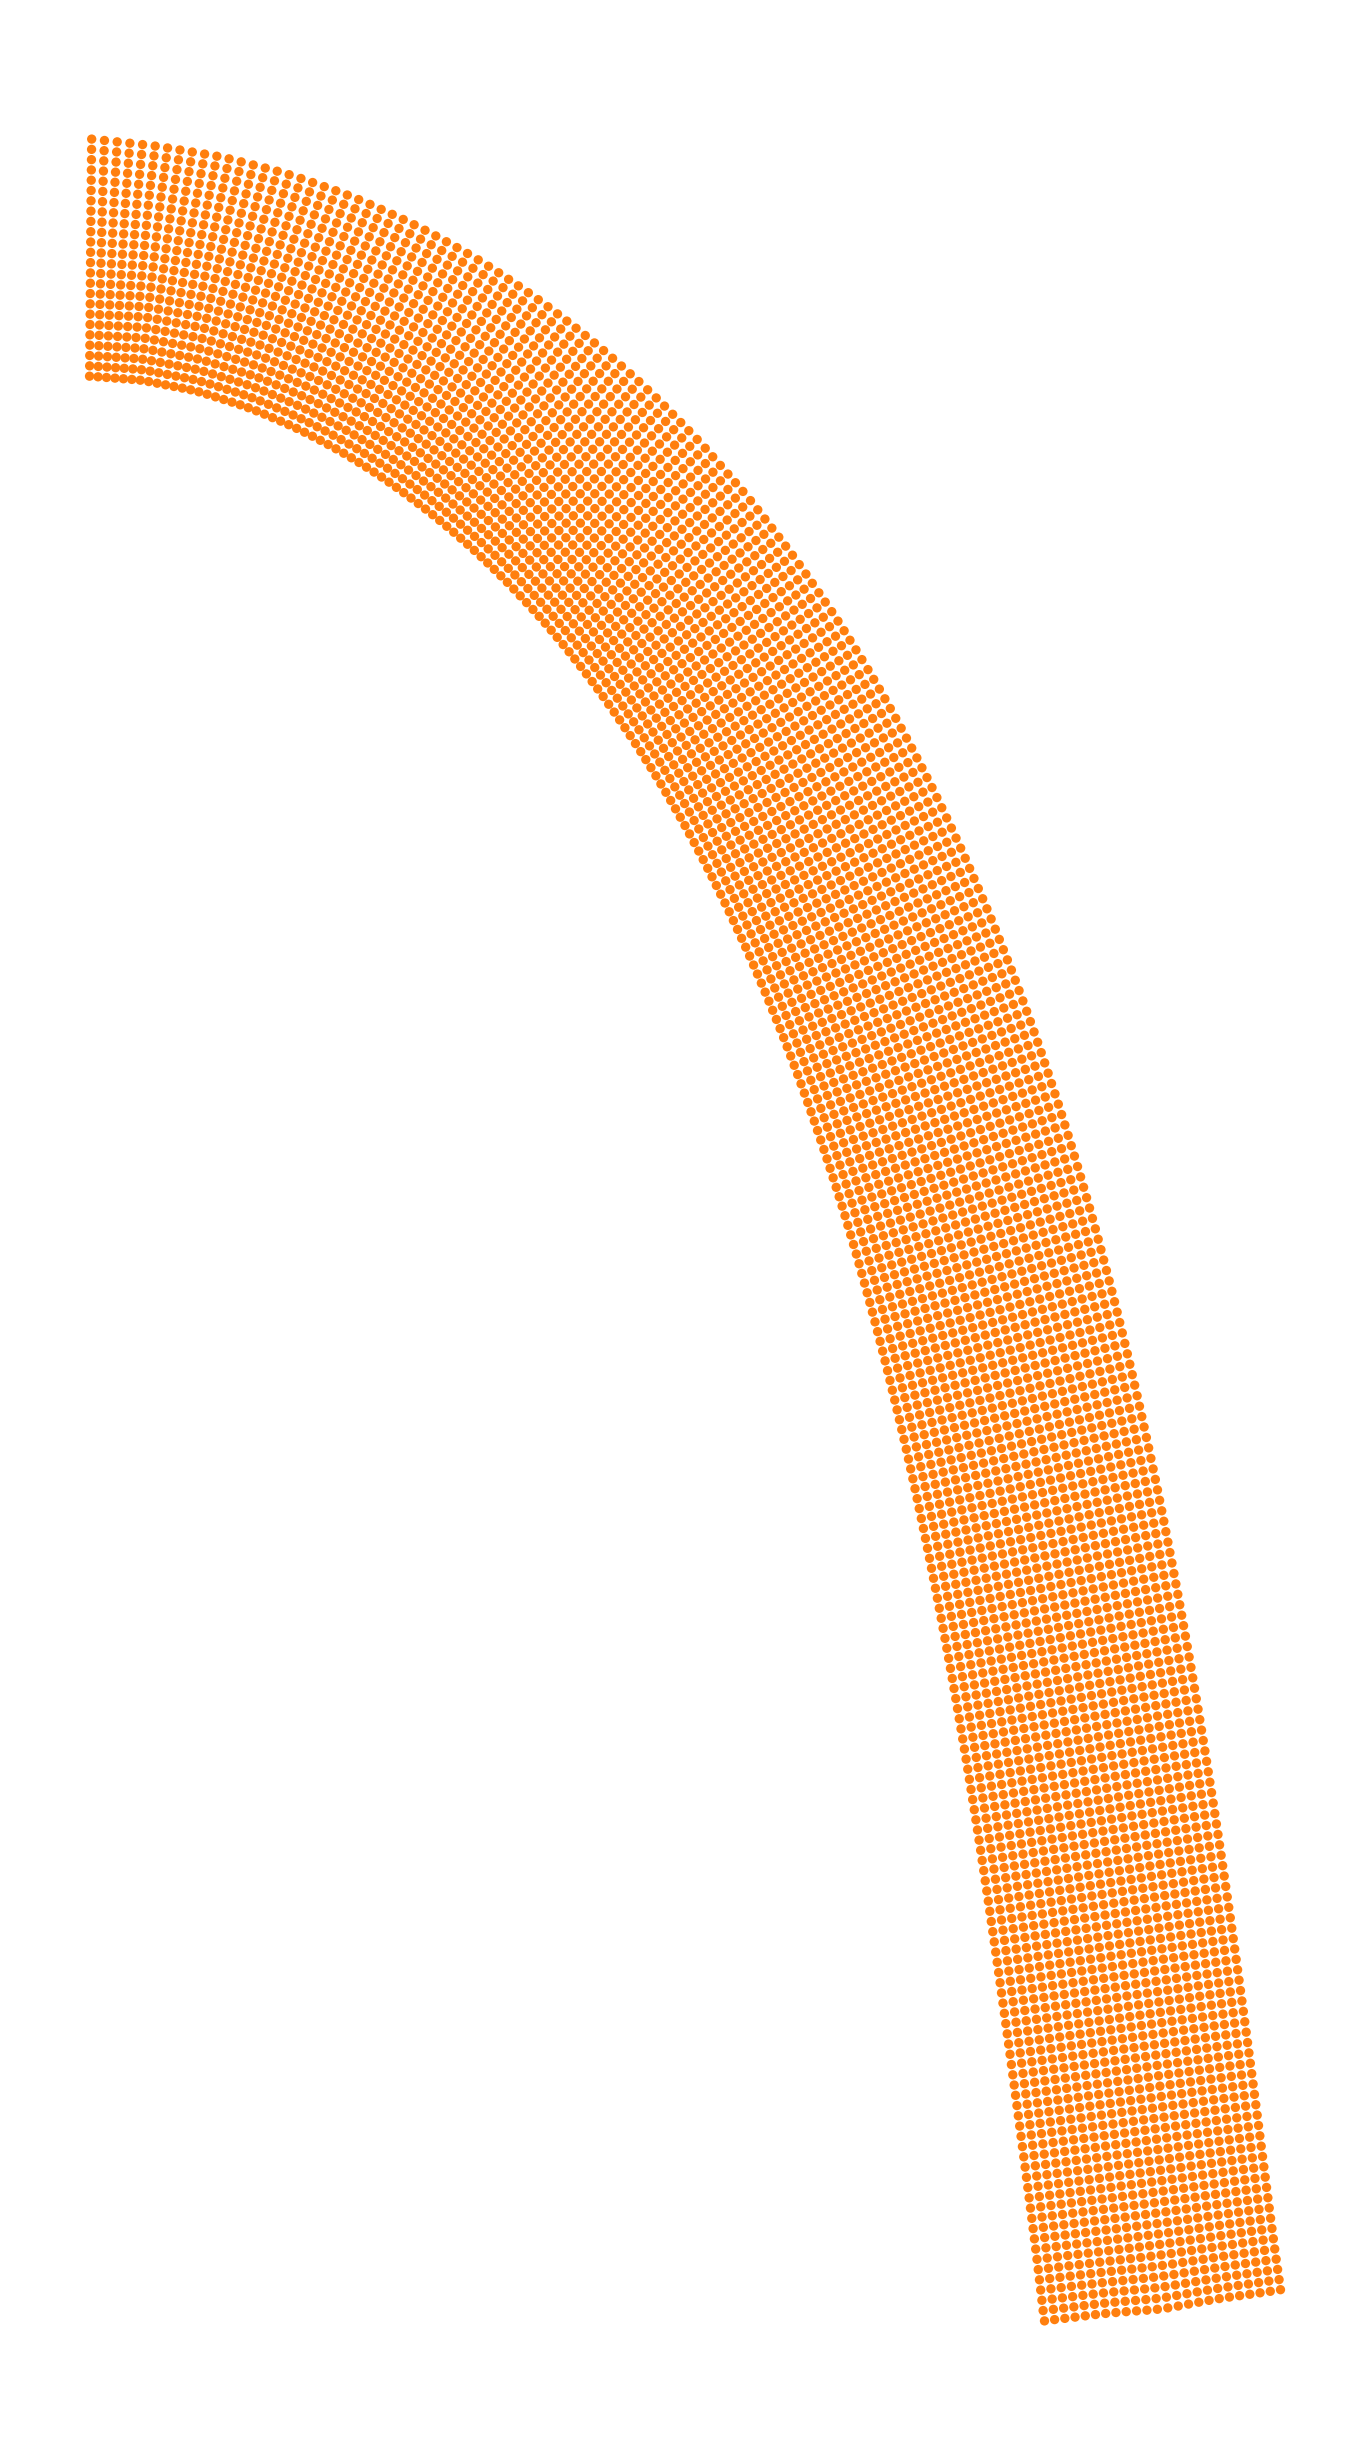

Array([[0.  ],
       [0.  ],
       [0.05],
       ...,
       [0.05],
       [0.05],
       [0.05]], dtype=float64)

In [9]:
print("--- Starting Newton Solver ---")
lam = mat.lame_parameters[0] * jnp.ones((num_mat_pts,))
mu = mat.lame_parameters[1] * jnp.ones((num_mat_pts,))
mp_state, uvw = newton_solve(
  mesh=mesh,
  mp_state=mp_state,
  bc=bc,
  du_guess=du_guess,
  load_steps=load_stps,
  gravity=gravity_vec,
  mpm_problem=mpm_problem,
  lame_lambda=lam,
  lame_mu=mu,
  post_cb=_post,
)

jax.block_until_ready(uvw)


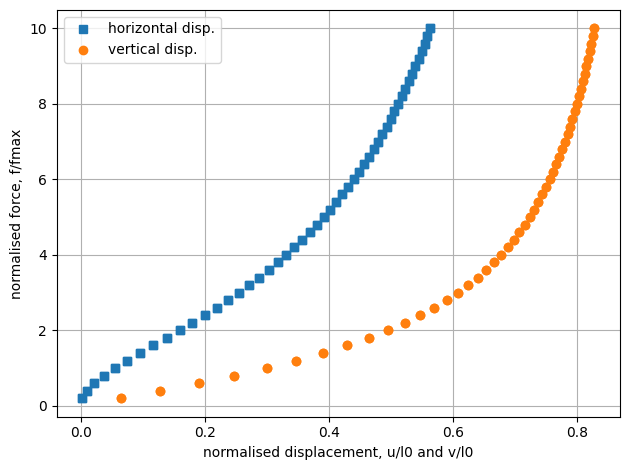

In [10]:
u = np.asarray(hist["u_norm"])
v = np.asarray(hist["v_norm"])
f = np.asarray(hist["f_norm"])

plt.figure()
plt.plot(u, f, marker="s", linestyle="None", label="horizontal disp.")
plt.plot(v, f, marker="o", linestyle="None", label="vertical disp.")
plt.xlabel("normalised displacement, u/l0 and v/l0")
plt.ylabel("normalised force, f/fmax")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

imageio.mimsave("mpm_cant.gif", frames, duration=0.3, loop=0)

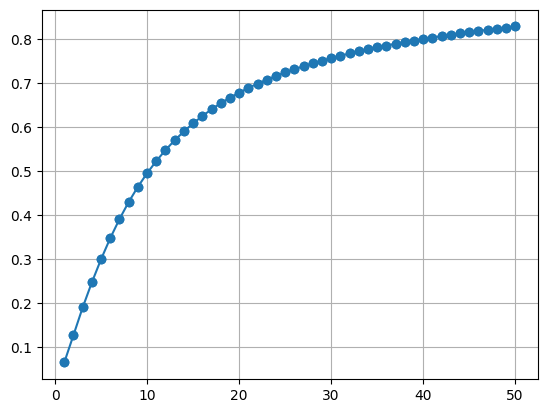

In [11]:
step = np.asarray(hist["step"])
v = np.asarray(hist["v_norm"])
order = np.argsort(step)
step, v = step[order], v[order]

plt.plot(step, v, marker="o")
plt.grid(True)
plt.show()
